# Real estate prices tracker

## EDA

### reading the dataset

In [1]:
import pandas as pd
import numpy as np


In [2]:
pwd()

'/home/claude/work'

In [3]:
data = pd.read_csv("magicbricks_mumbai_20260814_161732.csv")
data.head()

,OwnershipTypeD,ac,acD,achTdS,achTm,achTmS,actualOwner,ad_text,adroomD,agtCerStatus,...,tmsrt,transType,transactionTypeD,ty,ubicnt,url,userType,wapImgUrl,wapImgUrl1,waterStatus
0,NaN,11654.0,10 to 15 years,0,0,0,17800235,Sale Individual Mumbai Maharashtra India vir...,NaN,NaN,...,232027,Sale,Resale,10002,50,1-BHK-310-Sq-ft-Multistorey-Apartment-FOR-Sale...,Owner,https://img.staticmb.com/mbphoto/property/crop...,https://img.staticmb.com/mbphoto/property/crop...,NaN
1,NaN,11655.0,15 to 20 years,0,0,0,58928717,Sale Individual Mumbai Maharashtra India 100...,NaN,NaN,...,93000,Sale,Resale,10002,50,1-BHK-440-Sq-ft-Multistorey-Apartment-FOR-Sale...,Owner,https://img.staticmb.com/mbphoto/property/crop...,https://img.staticmb.com/mbphoto/property/crop...,NaN
2,Co-operative Society,11654.0,10 to 15 years,0,0,0,49937177,Sale Individual Mumbai Maharashtra India Sid...,NaN,N,...,52535,Sale,Resale,10003,50,1-BHK-365-Sq-ft-Builder-Floor-Apartment-FOR-Sa...,Owner,https://img.staticmb.com/mbphoto/property/crop...,https://img.staticmb.com/mbphoto/property/crop...,Water Availability 24 Hours Available
3,Co-operative Society,11654.0,10 to 15 years,0,0,0,66070239,Sale Individual Mumbai Maharashtra India 404...,NaN,NaN,...,223334,Sale,Resale,10002,50,1-BHK-525-Sq-ft-Multistorey-Apartment-FOR-Sale...,Owner,https://img.staticmb.com/mbphoto/property/crop...,https://img.staticmb.com/mbphoto/property/crop...,Water Availability 24 Hours Available
4,NaN,NaN,NaN,0,0,0,34200887,Sale Individual Mumbai Maharashtra India Bal...,NaN,NaN,...,220815,Sale,Resale,10003,50,1-BHK-500-Sq-ft-Builder-Floor-Apartment-FOR-Sa...,Owner,https://img.staticmb.com/mbphoto/property/crop...,https://img.staticmb.com/mbphoto/property/crop...,NaN


In [4]:
# print(f"no. of rows, cols : {data.shape}\n")
print(f"info : {data.info()}\n")
# print(f"desc : {data.describe()}\n")


<class 'pandas.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Columns: 225 entries, OwnershipTypeD to waterStatus
dtypes: bool(6), float64(45), int64(50), str(124)
memory usage: 51.6 KB
info : None



In [5]:
# columns

colnames = data.columns
for i in colnames:
    print(i)

    

OwnershipTypeD
ac
acD
achTdS
achTm
achTmS
actualOwner
ad_text
adroomD
agtCerStatus
allImgCt
allImgPath
amenFacingD
amenities
ampDesc
appExc
appExcProp
appExcRe
appSub
appVer
appovedAuthC
attrImg
auto_desc
availUnit
b2cCardEligibility
balconiesD
bathD
bd
bedroomD
bookingAmtExact
buyerCountbyPsm
cScore
ca
caCompNameD
caSqFt
carpAreaUnit
carpetArea
catAdd1
cg
cntvl
comFlag
covAreaUnit
covAreaUnitDesc
coverAreaUnitD
coveredArea
cowDays
cpmp
ct
ctName
ctVerifd
ctaDetailBean
ctaRuleId
dImgRf
dImgSrc
defaultAdddressGoogle
devId
devName
deviceType
dsla
dtldesc
ecd
encId
enc_Id
endDateT
endDt
exc
facingD
floorCsntrAllowed
floorD
floorNo
flooringTyD
floors
furnished
furnishedD
grpBky1
grpBky2
grpBky3
grpBky4
grpBky5
grpBky6
grpBky7
iba
id
image
imageCount
imageDate
imgCt
infraStatusList
investorguide
investorlisting
isAdvertiserOfThisListingAOwnerAndUnPaid
isCardDesc
isExcl
isLuxury
isLuxuryServiceAvailable
isPaidUser
isPrimeLocProp
isProjProp
isThisListingAPremiumOnly
lCct
lCtDate
la
landAreaUn

### selecting only needed cols

In [6]:
with open('colnames.txt','w') as file:
    for item in colnames:
        file.write(f"{item}\n")

In [7]:
with open("neededcols.txt", "r") as file:
    items = file.read().split(",")

In [8]:
items

['acD',
 'price',
 'priceD',
 'sqFtPrice',
 'minPrice',
 'maxPrice',
 'bedroomD',
 'bathD',
 'balconiesD',
 'carpetArea',
 'carpAreaUnit',
 'coveredArea',
 'covAreaUnit',
 'floorNo',
 'floors',
 'floorD',
 'furnishedD',
 'facingD',
 'amenFacingD',
 'propTypeD',
 'transactionTypeD',
 'possStatusD',
 'ecd',
 'rEcd',
 'landAreaUnit',
 'landAreaUnitD',
 'ct',
 'ctName',
 'loc',
 'locSeoName',
 'la',
 'pl',
 'prjname',
 'soc',
 'landmark',
 'landmarkDetails',
 'pmtLat',
 'pmtLong',
 'ltcoordGeo',
 'cg',
 'amenities',
 'luxAmenities',
 'luxAmenitiesD',
 'isLuxury',
 'isLuxuryServiceAvailable',
 'parkingD',
 'waterStatus',
 'powerStatusD',
 'maintenanceCharges',
 'maintenanceD',
 'flooringTyD',
 'reraValidity',
 'OwnershipTypeD',
 'postDateT',
 'modifiedDate',
 'lastAccessDate',
 'endDateT',
 'endDt',
 'cowDays',
 'dsla',
 'nriPref',
 'tenantsPreference',
 'propertyTitle',
 'adroomD',
 'caSqFt',
 'lmtDName']

In [9]:
cols_to_keep = items
existing_cols = [col for col in cols_to_keep if col in data.columns] 
data_needed_cols = data[existing_cols]

In [10]:
data_needed_cols.head(1)

,acD,price,priceD,sqFtPrice,minPrice,maxPrice,bedroomD,bathD,balconiesD,carpetArea,...,endDateT,endDt,cowDays,dsla,nriPref,tenantsPreference,propertyTitle,adroomD,caSqFt,lmtDName
0,10 to 15 years,1200000,12 Lac,3871.0,1090000,1200000,1,1,NaN,270.0,...,2026-12-25T18:14:57.000Z,"Dec 25, '26",0,2.0,NaN,Bachelors/Family,1BHK Multistorey Apartment for Resale in Anand...,NaN,310.0,Dadar West


In [11]:
data_needed_cols.to_csv(
    "data-with-neededcols.csv")

### Now we choose the columns we are gonna work with

In [12]:
imp_cols = ['acD','price','sqFtPrice','bedroomD','bathD','balconiesD','carpetArea','coveredArea','floorNo','floors','furnishedD','facingD','amenFacingD','propTypeD','transactionTypeD','possStatusD','ecd','ctName','locSeoName','prjname','landmark','lmtDName','ltcoordGeo','luxAmenitiesD','parkingD','waterStatus','powerStatusD','maintenanceCharges','maintenanceD','flooringTyD','reraValidity','OwnershipTypeD','tenantsPreference','postDateT','propertyTitle','adroomD']

In [13]:
working_dataset = data_needed_cols[imp_cols]
working_dataset.head(2)

,acD,price,sqFtPrice,bedroomD,bathD,balconiesD,carpetArea,coveredArea,floorNo,floors,...,powerStatusD,maintenanceCharges,maintenanceD,flooringTyD,reraValidity,OwnershipTypeD,tenantsPreference,postDateT,propertyTitle,adroomD
0,10 to 15 years,1200000,3871.0,1,1,NaN,270.0,310.0,1,5.0,...,NaN,NaN,NaN,NaN,NaN,NaN,Bachelors/Family,2026-08-12T18:14:57.000Z,1BHK Multistorey Apartment for Resale in Anand...,NaN
1,15 to 20 years,2000000,4545.0,1,1,NaN,317.0,440.0,Ground,4.0,...,NaN,NaN,NaN,NaN,NaN,NaN,Bachelors/Family,2026-08-12T16:51:50.000Z,1BHK Multistorey Apartment for Resale in Ganga...,NaN


In [14]:
print(working_dataset[['carpetArea','price']])

    carpetArea    price
0        270.0  1200000
1        317.0  2000000
2        300.0  1500000
3        525.0  1600000
4          NaN  1800000
5        364.0  1500000
6        230.0  1650000
7        160.0  1500000
8        252.0  1600000
9        338.0  1600000
10       108.0  1400000
11       550.0  1730000
12         NaN  1600000
13         NaN  1200000
14       350.0  1300000
15       850.0  2000000
16       375.0  1900000
17         NaN  1700000
18       250.0  2000000
19       350.0  1400000
20       324.0  1400000
21       328.0  1900000
22       425.0  1500000
23         NaN  2000000
24       342.0  1800000
25       216.0  2000000
26       297.0  1500000
27       300.0  1040000
28         NaN  1130000
29       375.0  1950000


### Data quality assessment

In [15]:
print(f"rows, cols: {working_dataset.shape}\n")

null_pct = (working_dataset.isnull().sum() / len(working_dataset) * 100).sort_values(ascending=False)
null_pct = null_pct[null_pct > 0]
print("% missing per column:\n")
print(null_pct.round(1))

rows, cols: (30, 36)

% missing per column:

parkingD              96.7
adroomD               96.7
waterStatus           90.0
maintenanceCharges    90.0
powerStatusD          90.0
maintenanceD          90.0
balconiesD            86.7
flooringTyD           86.7
reraValidity          86.7
luxAmenitiesD         83.3
amenFacingD           80.0
facingD               73.3
landmark              70.0
OwnershipTypeD        66.7
prjname               53.3
locSeoName            33.3
lmtDName              26.7
ltcoordGeo            26.7
acD                   26.7
floors                20.0
carpetArea            20.0
floorNo               20.0
sqFtPrice             13.3
coveredArea           13.3
possStatusD           10.0
dtype: float64


With only 30 rows in this scrape, any column missing more than ~70% of its values isn't usable as a predictor, there just isn't enough signal. Dropping those now rather than trying to impute noise.

In [16]:
high_missing = null_pct[null_pct > 70].index.tolist()
print("Dropping (too sparse for 30 rows):", high_missing)

df = working_dataset.drop(columns=high_missing).copy()
df.shape

Dropping (too sparse for 30 rows): ['parkingD', 'adroomD', 'waterStatus', 'maintenanceCharges', 'powerStatusD', 'maintenanceD', 'balconiesD', 'flooringTyD', 'reraValidity', 'luxAmenitiesD', 'amenFacingD', 'facingD']


(30, 24)

### Cleaning individual fields

In [17]:
# floorNo mixes numbers with the string 'Ground' -> treat Ground as floor 0
df['floorNo'] = df['floorNo'].replace({'Ground': '0'})
df['floorNo'] = pd.to_numeric(df['floorNo'], errors='coerce')

# ecd is an int date like 20260813 -> proper datetime
df['ecd'] = pd.to_datetime(df['ecd'].astype(str), format='%Y%m%d', errors='coerce')

# postDateT is an ISO timestamp string -> datetime
df['postDateT'] = pd.to_datetime(df['postDateT'], errors='coerce')

# ltcoordGeo is "lat,long" packed into one string -> split into two numeric cols
coords = df['ltcoordGeo'].str.split(',', expand=True)
df['latitude'] = pd.to_numeric(coords[0], errors='coerce')
df['longitude'] = pd.to_numeric(coords[1], errors='coerce')
df = df.drop(columns=['ltcoordGeo'])

df[['floorNo', 'ecd', 'postDateT', 'latitude', 'longitude']].head()

,floorNo,ecd,postDateT,latitude,longitude
0,1.0,2026-08-13,2026-08-12 18:14:57+00:00,19.020067,72.838078
1,0.0,2026-08-13,2026-08-12 16:51:50+00:00,19.465290,72.818999
2,2.0,2026-08-09,2026-08-08 23:55:35+00:00,19.442298,72.794513
3,4.0,2026-08-01,2026-08-01 07:13:11+00:00,19.205335,72.835366
4,1.0,2026-06-26,2026-06-26 13:07:51+00:00,NaN,NaN


In [18]:
# acD is a bucketed string like '10 to 15 years' -> map to a numeric midpoint
# so it can actually be used as a feature/plotted against price
age_map = {
    '0 to 1 years': 0.5,
    '1 to 5 years': 3,
    '5 to 10 years': 7.5,
    '10 to 15 years': 12.5,
    '15 to 20 years': 17.5,
    '20+ years': 25,
}
df['property_age_yrs'] = df['acD'].map(age_map)
df[['acD', 'property_age_yrs']].drop_duplicates()

,acD,property_age_yrs
0,10 to 15 years,12.5
1,15 to 20 years,17.5
4,NaN,NaN
6,5 to 10 years,7.5
10,Less than 5 years,NaN
24,New Construction,NaN


### Feature engineering

In [19]:
# recompute price per sqft from carpetArea and cross-check against the scraped sqFtPrice
df['price_per_sqft_calc'] = df['price'] / df['carpetArea']

check = df[['price', 'carpetArea', 'sqFtPrice', 'price_per_sqft_calc']].copy()
check['diff_pct'] = ((check['price_per_sqft_calc'] - check['sqFtPrice']) / check['sqFtPrice'] * 100).round(1)
check

,price,carpetArea,sqFtPrice,price_per_sqft_calc,diff_pct
0,1200000,270.0,3871.0,4444.444444,14.8
1,2000000,317.0,4545.0,6309.148265,38.8
2,1500000,300.0,4110.0,5000.000000,21.7
3,1600000,525.0,3048.0,3047.619048,-0.0
4,1800000,NaN,3600.0,NaN,NaN
5,1500000,364.0,3067.0,4120.879121,34.4
6,1650000,230.0,7174.0,7173.913043,-0.0
7,1500000,160.0,6944.0,9375.000000,35.0
8,1600000,252.0,4571.0,6349.206349,38.9
9,1600000,338.0,3404.0,4733.727811,39.1


`sqFtPrice` looks like it's computed off `coveredArea` (built-up area) rather than `carpetArea`, that's the likely source of the gap above. Worth deciding which area definition to standardize on. I'll use `price_per_sqft_calc` (carpet-area based) going forward since carpet area is the more buyer-relevant number in the Indian market.

In [20]:
# days on market as of today, a liquidity signal
df['days_since_posted'] = (pd.Timestamp.now(tz=df['postDateT'].dt.tz) - df['postDateT']).dt.days

# ordinal encode furnishing since it has a natural order
furnish_order = {'Unfurnished': 0, 'Semi-Furnished': 1, 'Furnished': 2}
df['furnished_ord'] = df['furnishedD'].map(furnish_order)

df[['postDateT', 'days_since_posted', 'furnishedD', 'furnished_ord']].head()

,postDateT,days_since_posted,furnishedD,furnished_ord
0,2026-08-12 18:14:57+00:00,8,Semi-Furnished,1
1,2026-08-12 16:51:50+00:00,8,Unfurnished,0
2,2026-08-08 23:55:35+00:00,12,Unfurnished,0
3,2026-08-01 07:13:11+00:00,20,Unfurnished,0
4,2026-06-26 13:07:51+00:00,55,Unfurnished,0


### Exploratory analysis

In [21]:
df[['price', 'carpetArea', 'coveredArea', 'floorNo', 'floors',
    'property_age_yrs', 'price_per_sqft_calc', 'days_since_posted']].describe()

,price,carpetArea,coveredArea,floorNo,floors,property_age_yrs,price_per_sqft_calc,days_since_posted
count,3.000000e+01,24.000000,26.000000,24.000000,24.000000,18.000000,24.000000,30.000000
mean,1.613333e+06,341.500000,428.346154,1.791667,4.083333,11.388889,5486.621682,37.133333
std,2.829077e+05,145.848641,189.586907,1.614585,2.145099,3.233808,2432.126489,37.836976
min,1.040000e+06,108.000000,150.000000,0.000000,1.000000,7.500000,2352.941176,7.000000
25%,1.425000e+06,265.500000,315.000000,0.000000,3.750000,7.500000,3928.571429,8.000000
50%,1.600000e+06,326.000000,440.000000,1.500000,4.000000,12.500000,5025.252525,13.000000
75%,1.875000e+06,366.750000,493.500000,3.000000,4.000000,12.500000,6319.162786,60.250000
max,2.000000e+06,850.000000,1000.000000,5.000000,12.000000,17.500000,12962.962963,129.000000


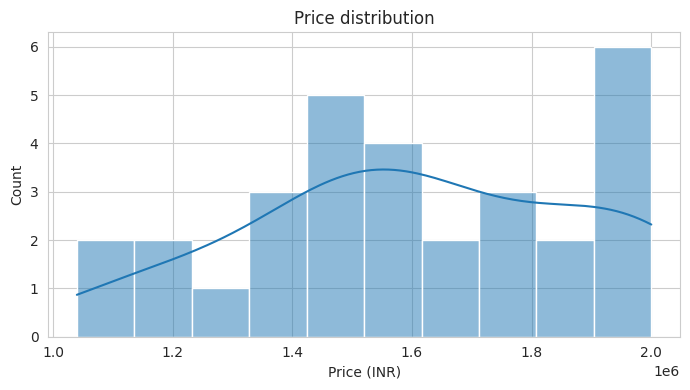

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')

fig, ax = plt.subplots(figsize=(7, 4))
sns.histplot(df['price'], bins=10, kde=True, ax=ax)
ax.set_title('Price distribution')
ax.set_xlabel('Price (INR)')
plt.tight_layout()
plt.show()

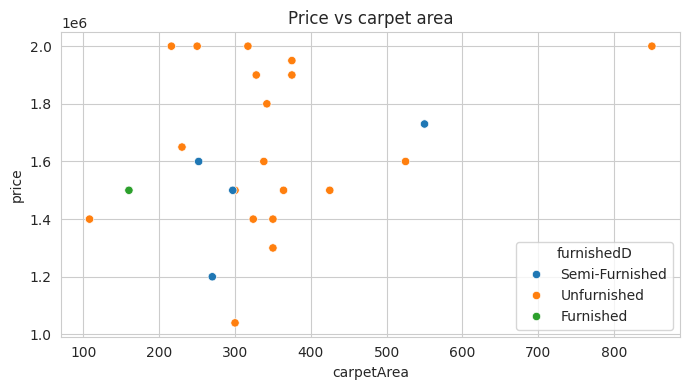

In [23]:
fig, ax = plt.subplots(figsize=(7, 4))
sns.scatterplot(data=df, x='carpetArea', y='price', hue='furnishedD', ax=ax)
ax.set_title('Price vs carpet area')
plt.tight_layout()
plt.show()

                                 mean  count
locSeoName                                  
Malvani                     2000000.0      1
Mira Road                   2000000.0      1
Motilal Nagar               1950000.0      1
Nalasopara East             1900000.0      3
Virar East                  1760000.0      5
Sai Wadi Madh               1730000.0      1
Nala Sopara                 1700000.0      1
Virar                       1600000.0      1
Bolinj                      1500000.0      1
Khar West                   1500000.0      1
Virar West                  1500000.0      1
Dadar West                  1200000.0      1
NL Complex                  1130000.0      1
Mahada Colony Andheri West  1040000.0      1


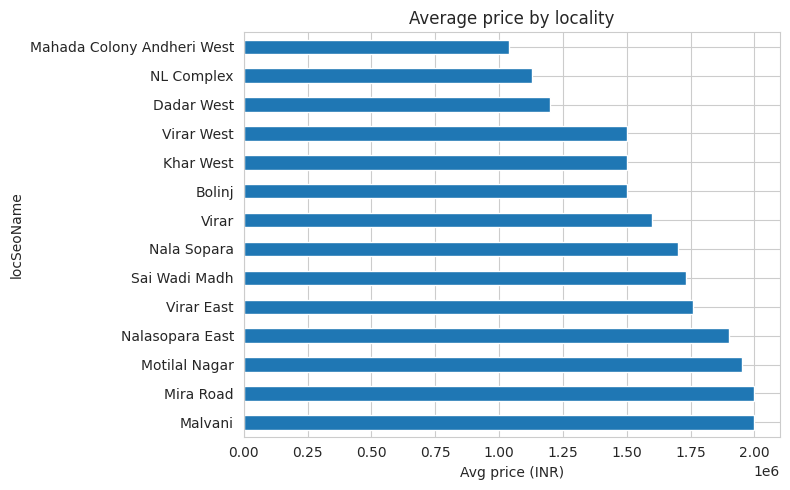

In [24]:
locality_price = (
    df.groupby('locSeoName')['price']
    .agg(['mean', 'count'])
    .sort_values('mean', ascending=False)
)
print(locality_price)

fig, ax = plt.subplots(figsize=(8, 5))
locality_price['mean'].plot(kind='barh', ax=ax)
ax.set_title('Average price by locality')
ax.set_xlabel('Avg price (INR)')
plt.tight_layout()
plt.show()

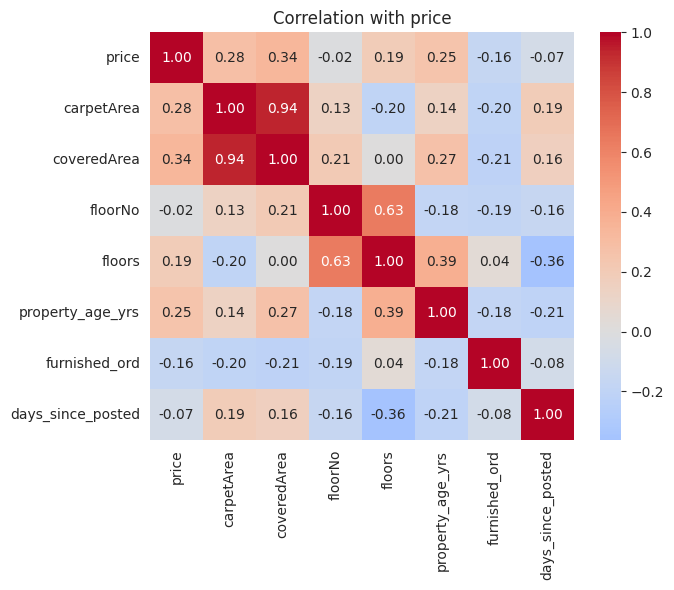

In [25]:
numeric_cols = ['price', 'carpetArea', 'coveredArea', 'floorNo', 'floors',
                 'property_age_yrs', 'furnished_ord', 'days_since_posted']
corr = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=ax)
ax.set_title('Correlation with price')
plt.tight_layout()
plt.show()

### Reality check before modeling

A few things stand out that need addressing before Phase 4 (modeling):

- **`bedroomD` is 1 for all 30 rows, and `ctName` is Mumbai for all 30.** This scrape looks like it was pulled from a filtered search (1 BHK, Mumbai only). A price model needs variation in bedroom count, property type, and locality to learn anything meaningful, right now most of the price spread has to be explained by area, floor, age, and locality alone.
- **30 rows is too small for train/test split or tree-based models.** Linear regression coefficients on this sample will be unstable. Treat the plots above as directional, not conclusive.
- **Columns like `parkingD`, `waterStatus`, `powerStatusD`, `maintenanceCharges`, `reraValidity` were dropped** for >70% missingness, they may come back once the scrape is larger and less sparse.

**Recommended next step:** re-run the scraper across multiple BHK configurations and possession statuses, aim for at least a few hundred rows before moving to Phase 4 modeling. The cleaning and feature engineering pipeline above will drop in as-is once you have that.

### Save cleaned dataset

In [26]:
df.to_csv("cleaned_dataset.csv", index=False)
print(f"Saved cleaned_dataset.csv -> {df.shape[0]} rows, {df.shape[1]} cols")

Saved cleaned_dataset.csv -> 30 rows, 29 cols
